In [1]:
# Numerical & Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Machine Learning
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

2026-05-19 17:04:45.627379: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779210285.868915      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779210285.942561      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779210286.574754      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779210286.574801      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779210286.574805      57 computation_placer.cc:177] computation placer alr

Libraries Imported Successfully


Cell 2 — Load Dataset

In [2]:
# Load train and test datasets

train_df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/human-activity-recognition-with-smartphones/train.csv')
test_df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/human-activity-recognition-with-smartphones/test.csv')

# Display first 5 rows
print("Train Dataset Shape:", train_df.shape)
print("Test Dataset Shape:", test_df.shape)

train_df.head()

Train Dataset Shape: (7352, 563)
Test Dataset Shape: (2947, 563)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


Cell 3 — Check Missing Values & Dataset Info

In [3]:
# Basic information about dataset
print("TRAIN DATA INFO")
print(train_df.info())

print("\nTEST DATA INFO")
print(test_df.info())

# Check missing values
print("\nMissing Values in Train Dataset:")
print(train_df.isnull().sum().sum())

print("\nMissing Values in Test Dataset:")
print(test_df.isnull().sum().sum())

TRAIN DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 31.6+ MB
None

TEST DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2947 entries, 0 to 2946
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 12.7+ MB
None

Missing Values in Train Dataset:
0

Missing Values in Test Dataset:
0


Cell 4 — Label Encoding

In [4]:
# Encode target labels (Activity → numbers)

label_encoder = LabelEncoder()

train_df['Activity'] = label_encoder.fit_transform(train_df['Activity'])
test_df['Activity'] = label_encoder.transform(test_df['Activity'])

# Check mapping
print("Activity Classes Mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(i, "=", class_name)

# Separate features and labels
X_train = train_df.drop(['Activity', 'subject'], axis=1)
y_train = train_df['Activity']

X_test = test_df.drop(['Activity', 'subject'], axis=1)
y_test = test_df['Activity']

print("\nShapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Activity Classes Mapping:
0 = LAYING
1 = SITTING
2 = STANDING
3 = WALKING
4 = WALKING_DOWNSTAIRS
5 = WALKING_UPSTAIRS

Shapes:
X_train: (7352, 561)
X_test: (2947, 561)


Cell 5 — Feature Scaling + Reshape for LSTM

In [5]:
# Standardize features (VERY IMPORTANT for LSTM)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for LSTM: (samples, timesteps=1, features)
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

print("LSTM Input Shape (Train):", X_train_lstm.shape)
print("LSTM Input Shape (Test):", X_test_lstm.shape)

LSTM Input Shape (Train): (7352, 1, 561)
LSTM Input Shape (Test): (2947, 1, 561)


Cell 6 — Convert Labels to One-Hot Encoding

In [6]:
# Convert labels to one-hot encoding
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

print("One-hot shape (train):", y_train_cat.shape)
print("One-hot shape (test):", y_test_cat.shape)

One-hot shape (train): (7352, 6)
One-hot shape (test): (2947, 6)


Cell 7 — Build LSTM Model

In [7]:
model = Sequential()

# LSTM layer
model.add(LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False))
model.add(Dropout(0.3))

# Dense layers
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))

# Output layer (6 classes)
model.add(Dense(6, activation='softmax'))

# Compile model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Model summary
model.summary()

2026-05-19 17:07:49.794391: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │       160,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,534 (634.90 KB)

 Trainable params: 162,534 (634.90 KB)

 Non-trainable params: 0 (0.00 B)

Cell 8 — Model Training

In [8]:
history = model.fit(
    X_train_lstm,
    y_train_cat,
    epochs=15,
    batch_size=64,
    validation_data=(X_test_lstm, y_test_cat),
    verbose=1
)

Epoch 1/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5858 - loss: 1.0613 - val_accuracy: 0.8962 - val_loss: 0.3162
Epoch 2/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9161 - loss: 0.2773 - val_accuracy: 0.9243 - val_loss: 0.2125
Epoch 3/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9447 - loss: 0.1777 - val_accuracy: 0.9311 - val_loss: 0.1768
Epoch 4/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9618 - loss: 0.1169 - val_accuracy: 0.9220 - val_loss: 0.2291
Epoch 5/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9647 - loss: 0.1057 - val_accuracy: 0.9311 - val_loss: 0.2216
Epoch 6/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9679 - loss: 0.0915 - val_accuracy: 0.9376 - val_loss: 0.1819
Epoch 7/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9777 - loss: 0.0752 - val_accuracy: 0.9406 - val_loss: 0.1791
Epoch 8/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9819 - loss: 0.0629 - val_accuracy: 0

Cell 9 — Model Evaluation (Accuracy)

In [9]:
# Evaluate on test data
loss, accuracy = model.evaluate(X_test_lstm, y_test_cat)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9474 - loss: 0.1862
Test Loss: 0.23344948887825012
Test Accuracy: 0.9429928660392761


Cell 10 — Predictions + Classification Report

In [10]:
# Predictions
y_pred = model.predict(X_test_lstm)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification report
print(classification_report(y_test, y_pred_classes))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
print(cm)

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       537
           1       0.94      0.90      0.92       491
           2       0.89      0.95      0.92       532
           3       0.94      0.99      0.97       496
           4       0.99      0.85      0.92       420
           5       0.90      0.97      0.94       471

    accuracy                           0.94      2947
   macro avg       0.95      0.94      0.94      2947
weighted avg       0.95      0.94      0.94      2947

[[524   0  13   0   0   0]
 [  0 442  48   0   0   1]
 [  0  27 505   0   0   0]
 [  0   0   0 492   2   2]
 [  0   0   0  16 358  46]
 [  0   0   0  13   0 458]]


📊 Cell 11 — Accuracy & Loss Graph

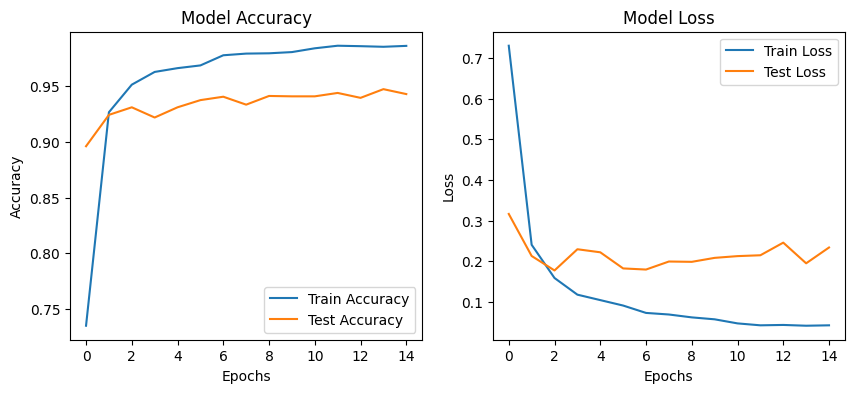

In [11]:
# Plot Accuracy
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
Cell 12 — Final Activity Prediction Example

In [12]:
# Example prediction (first 5 samples)
sample_pred = model.predict(X_test_lstm[:5])
sample_classes = np.argmax(sample_pred, axis=1)

# Convert back to original labels
predicted_labels = label_encoder.inverse_transform(sample_classes)

print("Predicted Activities:")
print(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted Activities:
['STANDING' 'STANDING' 'STANDING' 'STANDING' 'STANDING']
